In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from tqdm import tqdm
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

BATCH_SIZE = 128
NUM_CLASSES = 10
LATENT_DIM = 32
EPOCHS = 40
LR = 1e-3 # LR = 3e-4
BETA = 0.1

cpu


In [2]:
# Epoch 30: Train Loss = 0.0741, Val Loss = 0.0754

# Epoch 40: Train Loss = 0.1425, Val Loss = 0.1424

# class ConditionalVAE(nn.Module):
#     def __init__(self, latent_dim=20, num_classes=10):
#         super(ConditionalVAE, self).__init__()
#         self.latent_dim = latent_dim
#         self.num_classes = num_classes

#         self.encoder = nn.Sequential(
#             nn.Conv2d(1 + num_classes, 32, kernel_size=3, stride=2, padding=1),  # 14x14
#             nn.BatchNorm2d(32),
#             nn.ReLU(),
#             nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # 7x7
#             nn.BatchNorm2d(64),
#             nn.ReLU(),
#             nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),  # 7x7
#             nn.BatchNorm2d(128),
#             nn.ReLU(),
#             nn.Flatten()
#         )

#         self.fc_mu = nn.Linear(128 * 7 * 7, latent_dim)
#         self.fc_logvar = nn.Linear(128 * 7 * 7, latent_dim)

#         self.decoder_input = nn.Linear(latent_dim + num_classes, 128 * 7 * 7)
#         self.decoder = nn.Sequential(
#             nn.Unflatten(1, (128, 7, 7)),
#             nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
#             nn.BatchNorm2d(64),
#             nn.ReLU(),
#             nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
#             nn.BatchNorm2d(32),
#             nn.ReLU(),
#             nn.ConvTranspose2d(32, 1, kernel_size=3, stride=1, padding=1),
#         )

#     def encode(self, x, labels):
#         batch_size = x.size(0)
#         one_hot_labels = F.one_hot(labels, self.num_classes).float().to(device)  # [batch, 10]
#         one_hot_labels = one_hot_labels.view(batch_size, self.num_classes, 1, 1)  # [batch, 10, 1, 1]
#         one_hot_labels = one_hot_labels.expand(-1, -1, x.size(2), x.size(3))  # [batch, 10, 28, 28]

#         x_cond = torch.cat([x, one_hot_labels], dim=1)  # [batch, 11, 28, 28]

#         h = self.encoder(x_cond)

#         # параметры распределения
#         mu = self.fc_mu(h)
#         logvar = self.fc_logvar(h)

#         return mu, logvar

In [3]:
class LinearModule(nn.Module):

    def __init__(self, in_features: int, out_features: int, bias: bool = True):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.bias = bias

        self.weight = nn.Parameter(torch.Tensor(out_features, in_features))

        if bias:
            self.bias_param = nn.Parameter(torch.Tensor(out_features))
        else:
            self.register_parameter('bias_param', None)

        self.reset_parameters()

    def reset_parameters(self):
        nn.init.kaiming_uniform_(self.weight, a=np.sqrt(5))

        if self.bias_param is not None:
            fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.weight)
            bound = 1 / np.sqrt(fan_in) if fan_in > 0 else 0
            nn.init.uniform_(self.bias_param, -bound, bound)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        #y = x @ W^T + b
        # Поддержка разных размерностей ввода
        if x.dim() != 2:
            original_size = x.size()
            x = x.view(-1, original_size[-1])

        output = torch.matmul(x, self.weight.t())

        if self.bias_param is not None:
            output = output + self.bias_param

        if x.dim() != 2:
            output = output.view(*original_size[:-1], -1)

        return output

    def extra_repr(self):
        return f'in_features={self.in_features}, out_features={self.out_features}, bias={self.bias is not None}'


class ReLUModule(nn.Module):
    def __init__(self, inplace: bool = False):
        super().__init__()
        self.inplace = inplace

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        #ReLU(x) = max(0, x)
        if self.inplace:
            return torch.relu_(x)
        else:
            return torch.maximum(x, torch.zeros_like(x))

    def extra_repr(self):
        return f'inplace={self.inplace}'


class SigmoidModule(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        #Sigmoid(x) = 1 / (1 + exp(-x))
        return torch.where(x >= 0,
                          1 / (1 + torch.exp(-x)),
                          torch.exp(x) / (1 + torch.exp(x)))

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train dataset len: {len(train_dataset)}")
print(f"Test dataset len: {len(test_dataset)}")

class ConditionalVAE(nn.Module):
    def __init__(self, latent_dim=20, num_classes=10):
        super(ConditionalVAE, self).__init__()
        self.latent_dim = latent_dim
        self.num_classes = num_classes

        self.encoder = nn.Sequential(
            nn.Conv2d(1 + num_classes, 32, kernel_size=3, stride=2, padding=1),  # 14x14
            nn.BatchNorm2d(32),
            ReLUModule(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # 7x7
            nn.BatchNorm2d(64),
            ReLUModule(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),  # 7x7
            nn.BatchNorm2d(128),
            ReLUModule(inplace=True),
            nn.Flatten()
        )

        self.fc_mu = LinearModule(128 * 7 * 7, latent_dim)
        self.fc_logvar = LinearModule(128 * 7 * 7, latent_dim)

        self.decoder_input = LinearModule(latent_dim + num_classes, 128 * 7 * 7)

        self.decoder = nn.Sequential(
            nn.Unflatten(1, (128, 7, 7)),
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(64),
            ReLUModule(inplace=True),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32),
            ReLUModule(inplace=True),
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=1, padding=1),
            SigmoidModule()  #
        )

    def encode(self, x, labels):
        batch_size = x.size(0)
        one_hot_labels = F.one_hot(labels, self.num_classes).float().to(device)
        one_hot_labels = one_hot_labels.view(batch_size, self.num_classes, 1, 1)
        one_hot_labels = one_hot_labels.expand(-1, -1, x.size(2), x.size(3))

        x_cond = torch.cat([x, one_hot_labels], dim=1)

        h = self.encoder(x_cond)

        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, labels):
        one_hot_labels = F.one_hot(labels, self.num_classes).float().to(device)
        z_cond = torch.cat([z, one_hot_labels], dim=1)

        h = self.decoder_input(z_cond)
        reconstruction = self.decoder(h)
        return reconstruction

    def forward(self, x, labels):
        mu, logvar = self.encode(x, labels)
        z = self.reparameterize(mu, logvar)
        reconstruction = self.decode(z, labels)
        return reconstruction, mu, logvar

    def generate(self, z, labels):
        with torch.no_grad():
            generated = self.decode(z, labels)
        return generated

def vae_loss(recon_x, x, mu, logvar, beta=0.1):
    # binary_cross_entropy вместо with_logits, так как уже есть Sigmoid в декодере
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction='mean')

    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

    total_loss = recon_loss + beta * kl_loss

    return total_loss, recon_loss, kl_loss


model = ConditionalVAE(latent_dim=LATENT_DIM, num_classes=NUM_CLASSES).to(device)

optimizer = optim.Adam(model.parameters(), lr=LR)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 588kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.44MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.67MB/s]


Train dataset len: 60000
Test dataset len: 10000


In [5]:
print("\nLinear в модели:")
for name, module in model.named_modules():
    if isinstance(module, LinearModule):
        print(f"  {name}: {module}")


Linear в модели:
  fc_mu: LinearModule(in_features=6272, out_features=32, bias=True)
  fc_logvar: LinearModule(in_features=6272, out_features=32, bias=True)
  decoder_input: LinearModule(in_features=42, out_features=6272, bias=True)


In [6]:
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS}')

    for batch_idx, (data, labels) in enumerate(pbar):
        data = data.to(device)
        labels = labels.to(device)

        recon_batch, mu, logvar = model(data, labels)
        loss, recon_loss, kl_loss = vae_loss(recon_batch, data, mu, logvar, beta=BETA)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        pbar.set_postfix({
            'Loss': loss.item(),
            'Recon': recon_loss.item(),
            'KL': kl_loss.item()
        })

    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for data, labels in test_loader:
            data = data.to(device)
            labels = labels.to(device)
            recon_batch, mu, logvar = model(data, labels)
            loss, _, _ = vae_loss(recon_batch, data, mu, logvar, beta=BETA)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(test_loader)
    val_losses.append(avg_val_loss)

    print(f'Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}')


Epoch 1/40: 100%|██████████| 469/469 [03:26<00:00,  2.27it/s, Loss=0.169, Recon=0.133, KL=0.359]


Epoch 1: Train Loss = 0.2033, Val Loss = 0.1725


Epoch 2/40: 100%|██████████| 469/469 [03:23<00:00,  2.30it/s, Loss=0.16, Recon=0.126, KL=0.336]


Epoch 2: Train Loss = 0.1684, Val Loss = 0.1626


Epoch 3/40: 100%|██████████| 469/469 [03:23<00:00,  2.30it/s, Loss=0.17, Recon=0.131, KL=0.39]


...

Epoch 38: Train Loss = 0.1425, Val Loss = 0.1426


Epoch 39/40: 100%|██████████| 469/469 [03:25<00:00,  2.29it/s, Loss=0.145, Recon=0.108, KL=0.367]


Epoch 39: Train Loss = 0.1423, Val Loss = 0.1420


Epoch 40/40: 100%|██████████| 469/469 [03:23<00:00,  2.30it/s, Loss=0.136, Recon=0.101, KL=0.358]


Epoch 40: Train Loss = 0.1423, Val Loss = 0.1422


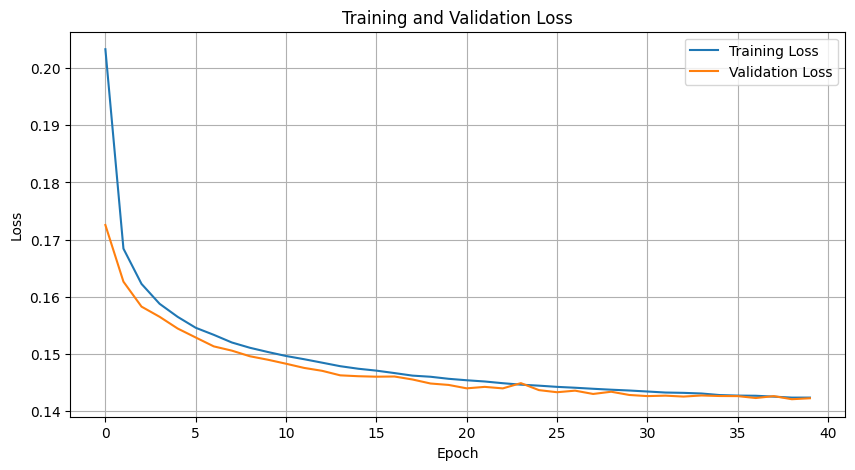

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

torch.save(model.state_dict(), 'conditional_vae_mnist_custom.pth')

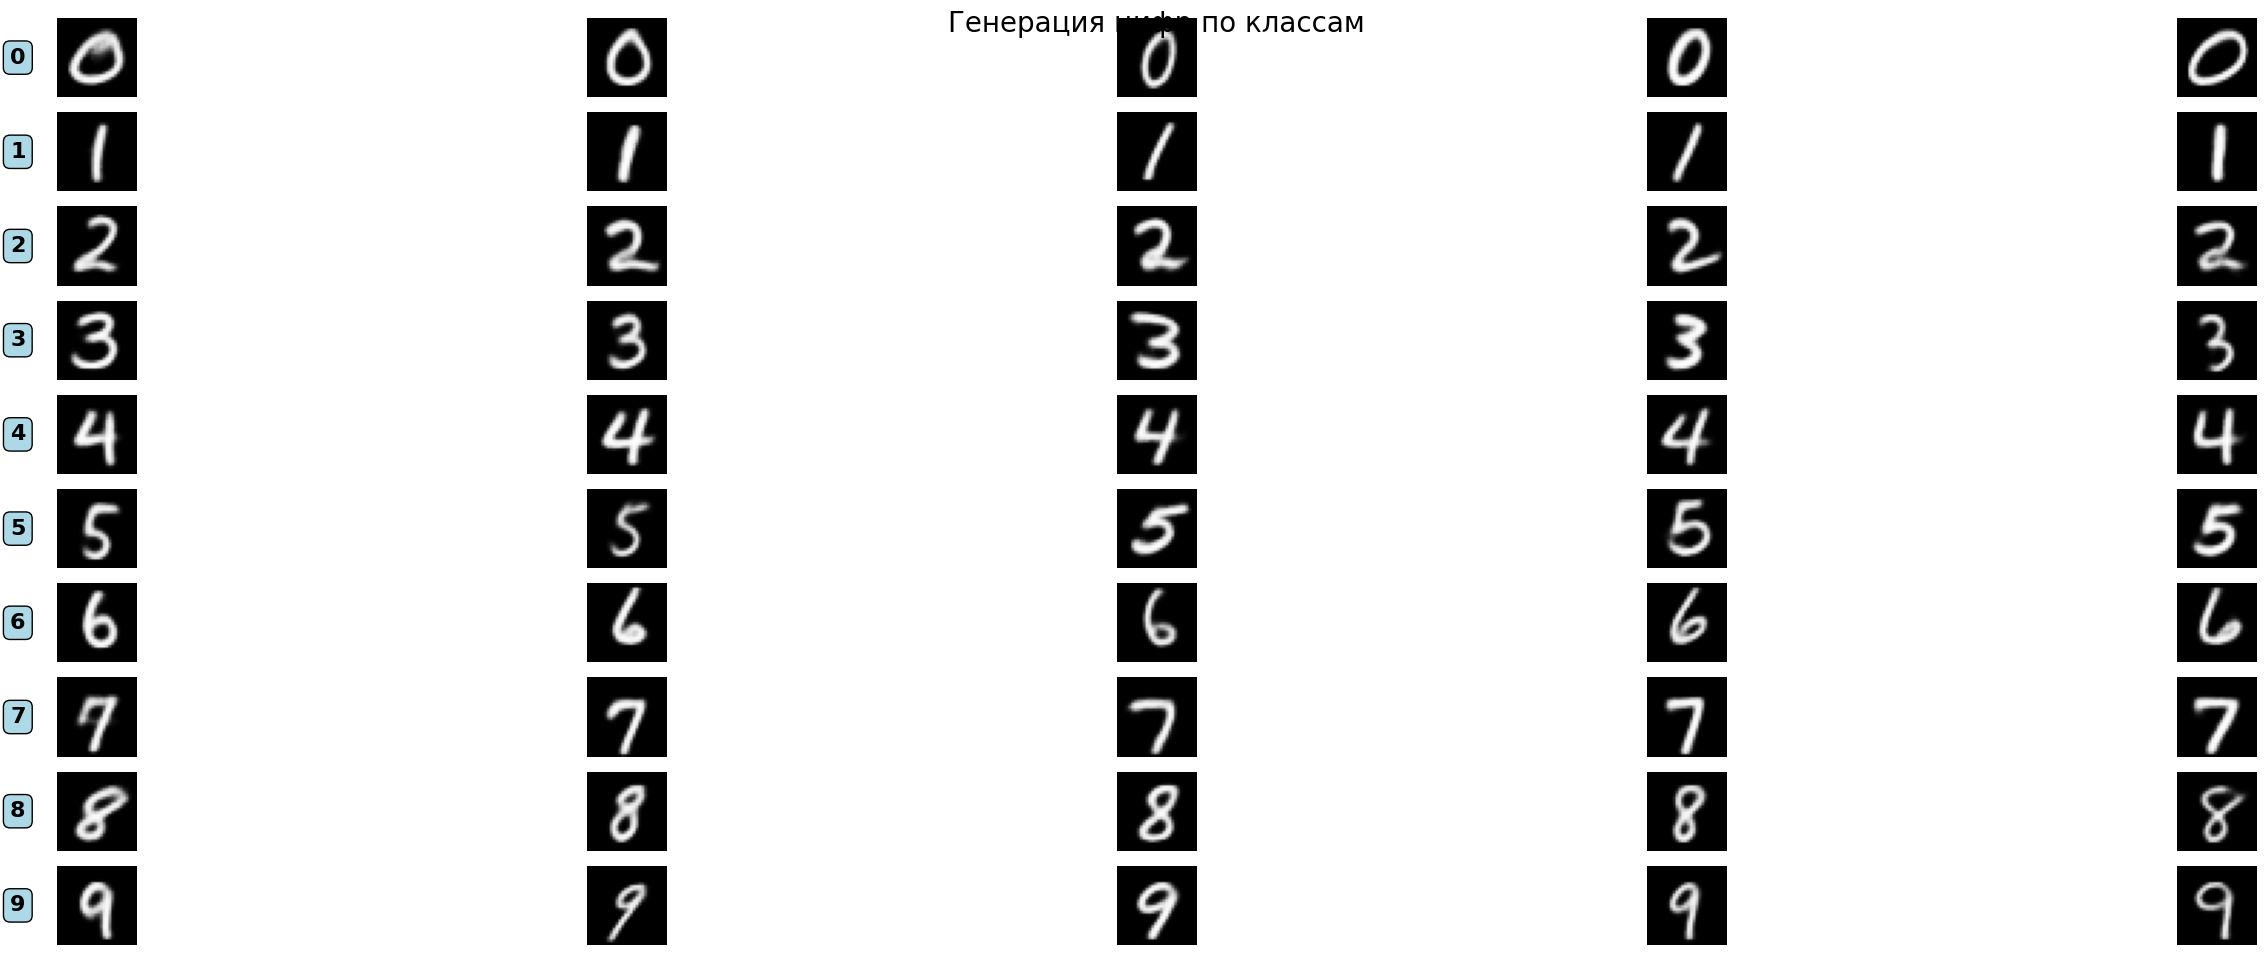

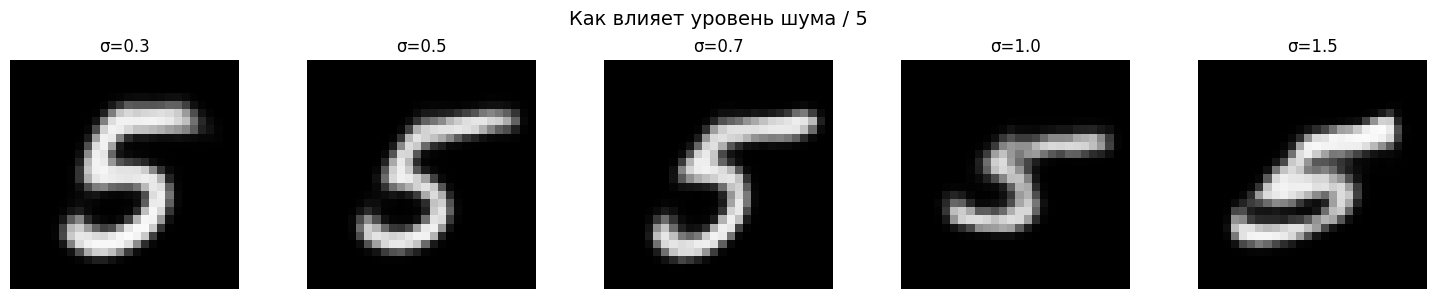

In [8]:
def generate_and_display_by_class(model, num_samples=5, figsize=(20, 12)):
    model.eval()
    plt.figure(figsize=figsize, dpi=100)

    with torch.no_grad():
        for digit in range(NUM_CLASSES):
            labels = torch.full((num_samples,), digit, dtype=torch.long).to(device)
            z = torch.randn(num_samples, LATENT_DIM).to(device) * 0.7
            generated = model.generate(z, labels)

            for j in range(num_samples):
                ax = plt.subplot(NUM_CLASSES, num_samples, digit * num_samples + j + 1)
                img = generated[j].cpu().squeeze().numpy()

                ax.imshow(img, cmap='gray', vmin=0, vmax=1)
                ax.axis('off')

                if j == 0:
                    ax.text(-0.5, 0.5, f'{digit}',
                           transform=ax.transAxes,
                           fontsize=16, fontweight='bold',
                           verticalalignment='center',
                           horizontalalignment='center',
                           bbox=dict(boxstyle="round,pad=0.3",
                                   facecolor='lightblue',
                                   edgecolor='black'))

    plt.suptitle('Генерация цифр по классам',
                 fontsize=20, fontweight='medium', y=0.95)
    plt.tight_layout()
    plt.show()

def test_different_noise_levels(model, digit=5):
    model.eval()
    noise_levels = [0.3, 0.5, 0.7, 1.0, 1.5]
    fig, axes = plt.subplots(1, len(noise_levels), figsize=(15, 3))

    with torch.no_grad():
        for i, noise_std in enumerate(noise_levels):
            torch.manual_seed(42 + i)
            z = torch.randn(1, LATENT_DIM).to(device) * noise_std
            label = torch.tensor([digit], dtype=torch.long).to(device)
            generated = model.generate(z, label)

            ax = axes[i]
            img = generated[0].cpu().squeeze().numpy()
            ax.imshow(img, cmap='gray', vmin=0, vmax=1)
            ax.set_title(f'σ={noise_std}', fontsize=12)
            ax.axis('off')

    plt.suptitle(f'Как влияет уровень шума / {digit}', fontsize=14)
    plt.tight_layout()
    plt.show()

generate_and_display_by_class(model, num_samples=5, figsize=(30, 10))
test_different_noise_levels(model)